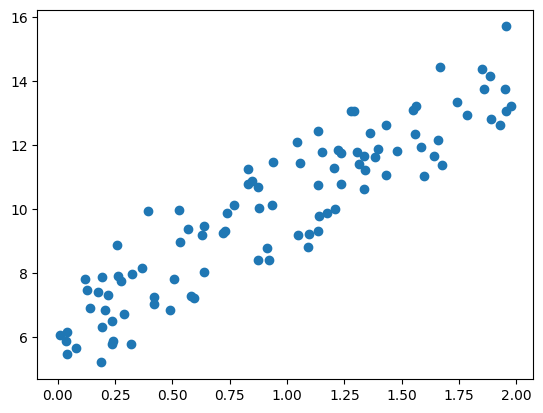

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#랜덤고정
np.random.seed(0)
#y = 4X+6 을 근사 (w1=4,w2=6).임의의값은 노이즈를 위해 만듦
X=2*np.random.rand(100,1)
y=6 +4 * X+np.random.randn(100,1)
#X, y 데이터 세트 산점도로 시각화
plt.scatter(X, y)

In [6]:
#비용함수 정의
def get_cost(y,y_pred):
    N=len(y)
    cost=np.sum(np.square(y-y_pred))/N
    return cost


# w1와w0를 업데이트할 w1_update,w0_update를 반환
def get_weight_updates(w1,w0,X,y,learning_rate=0.01):
    N=len(y)
    #먼저 w1_update,w0_update를 각각 w1,w0의 shape와 동일한 크기를 가진 0값으로 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
    #예측 배열 계산하고 예측과 실제값의 차이계산
    y_pred=np.dot(X,w1.T)+w0
    diff=y-y_pred

    #w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬생성
    w0_factors=np.ones((N,1))
    #w1과 w0를 업데이트할 w1_update와 w0_update 계산
    w1_update=-(2/N)*learning_rate*(np.dot(X.T,diff))
    w0_update=-(2/N)*learning_rate*(np.dot(w0_factors.T,diff))
    
    return w1_update,w0_update




In [7]:
#위 함수를 이용해 가중치 업데이트하는 함수 생성
#입력 인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0를 업데이트 적용함
def gradient_descent_steps(X, y, iters=10000):
    #w0와 w1을 모두 초기화
    w0=np.zeros((1,1))
    w1=np.zeros((1,1))

    #인자로 주어진 iters 만큼 반복적으로 get_weight_updates 함수를 호출해 w0와 w1을 업데이트 수행
    for ind in range(iters):
        w1_update,w0_update=get_weight_updates(w1,w0,X,y,learning_rate=0.01)
        w1=w1-w1_update
        w0=w0-w0_update

    return w1,w0

In [8]:
#경사하강법의 예측오류 계산
w1,w0=gradient_descent_steps(X,y,iters=10000)
print("w1:{0:.3f},w0:{1:.3f}".format(w1[0,0],w0[0,0]))

#최종 비용함수 값 계산
y_pred=w1[0,0]*X+w0
print("Gradient Descent Total Cost: {0:.4f}".format(get_cost(y,y_pred)))

w1:3.968,w0:6.222
Gradient Descent Total Cost: 0.9924


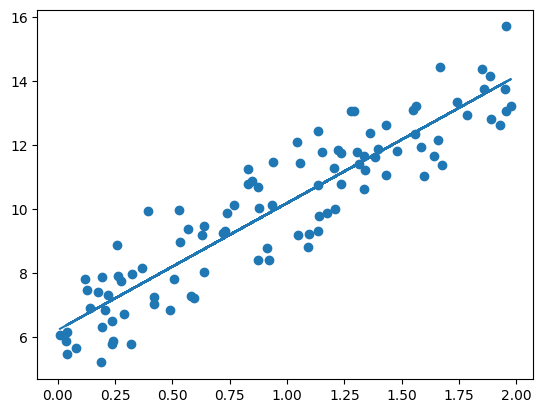

In [9]:
#회귀선 시각화
plt.scatter(X, y)
plt.plot(X, y_pred)


In [10]:
#확률적 경사하강법 구현
def stochastic_gradient_descent_steps(X, y,batch_size=10, iters=10000):
    #w0와 w1을 모두 초기화
    w0=np.zeros((1,1))
    w1=np.zeros((1,1))

    #인자로 주어진 iters 만큼 반복적으로 get_weight_updates 함수를 호출해 w0와 w1을 업데이트 수행
    for ind in range(iters):
        np.random.seed(ind)
        #전체 X,y 데이터에서 랜덤하게 batch_size 만큼 데이터 추출해 sample_X,sample_y 저장
        stochastic_random_index=np.random.permutation(X.shape[0])
        sample_X=X[stochastic_random_index]
        sample_y=y[stochastic_random_index]
        #랜덤하게 batch_size 만큼 추출한 데이터 기반으로 w0와 w1을 업데이트 수행
        w1_update,w0_update=get_weight_updates(w1,w0,sample_X,sample_y,learning_rate=0.01)
        w1=w1-w1_update
        w0=w0-w0_update

    return w1,w0

In [11]:
#회귀계수 및 예측 오류비용 계산
w1,w0=stochastic_gradient_descent_steps(X,y,iters=10000)
print("w1: ",round(w1[0,0],3),"w0: ",round(w0[0,0],3))
y_pred=w1[0,0]*X+w0
print("Stochastic Gradient Descent Total Cost:{0:.4f}".format(get_cost(y,y_pred)))


w1:  3.968 w0:  6.222
Stochastic Gradient Descent Total Cost:0.9924


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_boston
import warnings
warnings.filterwarnings("ignore")   
%matplotlib inline

#보스턴 데이터세트 로드
#버전1.2부터 보스턴 데이터 삭제되어 load 불가능
boston = load_boston()

#보스턴 데이터 세트 DataFrame으로 변환
bostonDF=pd.DataFrame(boston.data,columns=boston.feature_names)

#보스턴 데이터 세트의 타겟 배열은 주택 가격, 이를 PRICE 칼럼으로 DataFrame에 추가
bostonDF['PRICE']=boston.target
print('boston 데이터세트 크기:',bostonDF.shape)
bostonDF.head()


ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [ ]:
#각 칼럼이 회귀에 미치는 영향 시각화
#2개의 행과 4개의 열을 가진 subplots 이용, axs는 4x2개의 ax를 가짐
fig, axs = plt.subplots(figsize=(16, 8), ncols=4, nrows=2)
lm_features = ['RM', 'ZN', 'INDUS', "NOX", 'AGE', "PTRATIO", 'LSTAT', 'RAD']
for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i % 4
    #시본의 regplot을 이용하여 회귀선과 산점도 그리기
    sns.regplot(x=feature, y='PRICE', data=bostonDF, ax=axs[row, col])



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#PRICE 칼럼을 y_target으로, 나머지 칼럼을 X_data로 분리
y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

#학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size=0.3, random_state=156)

#선형회귀 OLS로 학습/예측/평가 수행
lr = LinearRegression()
lr.fit(X_train, y_train)

#예측 및 평가
y_pred = lr.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print('MSE: {0:.3f}, RMSE : {1:.3f}'.format(mse, rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

#모델의 절편값과 회귀계수 확인
print('절편:', lr.intercept_)
print('회귀계수:', np.round(lr.coef_, 1))

#회귀계수를 큰 값 순으로 정렬하기 위해 Series로 생성. 인덱스 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns )
coeff.sort_values(ascending=False)

In [ ]:
#교차 검증으로 MSE와 RMSE 측정
from sklearn.model_selection import cross_val_score

#데이터 분리
y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

#LinearRegression 객체 생성
Ir = LinearRegression()

#cross_val_score()로 5 폴드 세트로 MSE를 구한 뒤 이를 기반으로 다시 RMSE 구함.
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

#cross_val_score(scoring="neg_mean_squared_error")로 반환된 값은 모두 음수
print('5 folds의 개별 Negative MSE scores:', np.round(neg_mse_scores, 2))
print('5 folds의 개별 RMSE scores:', np.round(rmse_scores, 2))
print('5 folds의 평균 RMSE:', '{0:.3f}'.format(avg_rmse))



In [14]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0,1],[2,3]]의 2x2 행렬 생성
X = np.arange(4).reshape(2, 2)
print ('일차단항식 계수피처 : \n ',X)

#degree=2인 2차 다항식으로 변환하기위해 PolynomialFeatures를 이용해 변환
poly = PolynomialFeatures (degree=2)
poly. fit(X)
poly_ftr = poly. transform(X)
print ('변환된 2차 다항식 계수피처 : \n', poly_ftr)




일차단항식 계수피처 : 
  [[0 1]
 [2 3]]
변환된 2차 다항식 계수피처 : 
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [15]:
#3차 다항식 변환
def polynomial_func (X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4* X[:,1]**3
    return y

#2x2 배열 생성
x = np. arange(4).reshape (2,2)
print('일차 단항식 계수 feature:\n',x)

#3차 다항식 변환
y= polynomial_func(x)
print('3차 다항식 변환 feature:\n',y)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
3차 다항식 변환 feature:
 [  5 125]


In [17]:
from sklearn.linear_model import LinearRegression
#3차 다항식 변환
poly_ftr = PolynomialFeatures (degree=3).fit_transform(X)
print('3차 다항식 계수 feature:\n',poly_ftr)

#linear regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr,y)
print('polynomial 회귀 계수:\n',np.round(model.coef_,3))
print('polynomial 회귀 shape:\n',model.coef_.shape)

3차 다항식 계수 feature:
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
polynomial 회귀 계수:
 [0.    0.18  0.18  0.36  0.541 0.721 0.721 1.081 1.622 2.342]
polynomial 회귀 shape:
 (10,)


In [19]:
#파이프 라인 객체를 통한 다항회귀 구현
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y
#파이프 라인 객체로 streamline하게 Polynomial feature 변환과 linear regression 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),('linear', LinearRegression())])

#임의의 X,y 데이터 생성
x = np.arange(4) .reshape(2,2)
y = polynomial_func(X)
model = model. fit(X, y)

#학습된 모델을 이용한 예측
print('Polynomial 회귀계수\n', np.round(model.named_steps["linear"].coef_, 2))


Polynomial 회귀계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


Degree 1 회귀계수는 [-1.61] 입니다.
Degree 1 MSE = 0.4077
Degree 4 회귀계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE = 0.0432
Degree 15 회귀계수는 [-2.98294000e+03  1.03899810e+05 -1.87416889e+06  2.03717079e+07
 -1.44873919e+08  7.09318606e+08 -2.47066970e+09  6.24564152e+09
 -1.15677108e+10  1.56895778e+10 -1.54006881e+10  1.06457877e+10
 -4.91380459e+09  1.35920482e+09 -1.70381868e+08] 입니다.
Degree 15 MSE = 182251579.5917


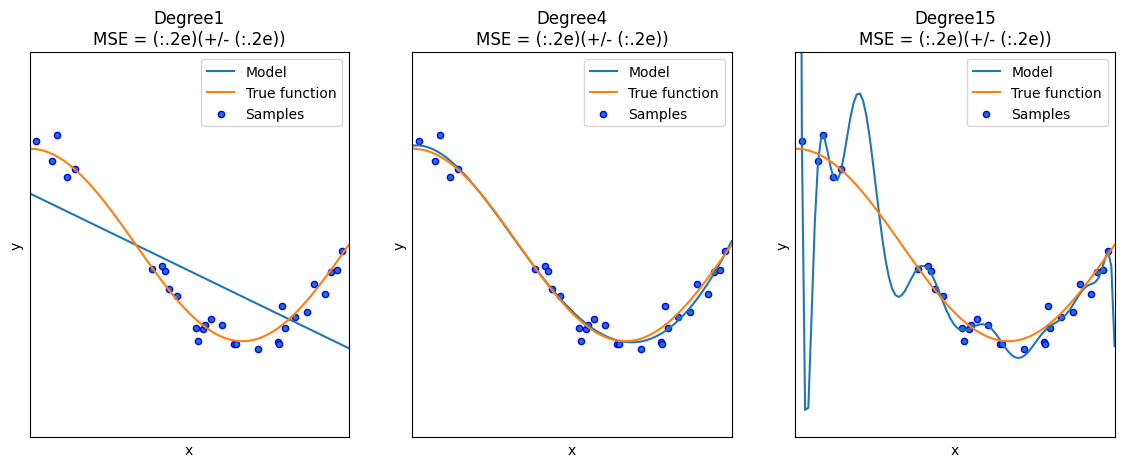

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

#임의의 값으로 구성된 X값에 대해 코사인 변환값을 반환
def true_fun (X):
    return np.cos(1.5 * np.pi * X)

#X는 0~1사이의 임의의 값으로 구성된 30개의 데이터
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

#y는 X값에 코사인 변환을 한 후 임의의 노이즈를 더한 값
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14, 5))
#다항식의 차수를 1, 4, 15로 변경하면서 예측결과 비교
degrees = [1, 4, 15]

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    #개별 degree별로 polynomial 변환
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
    ("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)

    #교차 검증으로 다항 회귀 평가
    scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)
    #pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 통한 회귀계수 추출
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('Degree {0} 회귀계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE = {1:.4f}'.format(degrees[i], -1*np.mean(scores)))

    #0부터 1까지 테스트 데이터를 100개로 나눠 예측 수행
    #테스트 데이터에 회귀예측을 수행하고 예측곡선과 실제 곡선을 그려서 비교
    X_test = np.linspace(0, 1, 100)
    
    #예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")    
    #실제값 곡선
    plt.plot(X_test, true_fun(X_test), '-', label="True function")
    #샘플 데이터
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    

    plt.xlabel("x"); plt.ylabel ("y"); plt.xlim((0, 1)); plt.ylim((-2, 2)); plt.legend(loc="best")
    plt. title("Degree{}\nMSE = (:.2e)(+/- (:.2e))". format(degrees[i], -scores.mean(), scores.std()))
plt.show()

    

    
